In [1]:
%run ../bootstrap.py

[Bootstrap] cwd=/home/ikk/renal-calculi-classificaction | seed=57


In [2]:
from src.data.preprocessment import *
from src.utils.visualization import *
from pathlib import Path
import matplotlib.pyplot as plt
from src.utils.io import load_image, load_mask

In [ ]:

#convertir .tif a .png
from_tif_to_png(surface_section_path)
#normalitzar el noms usant snakecase
normalize_name(surface_section_path)


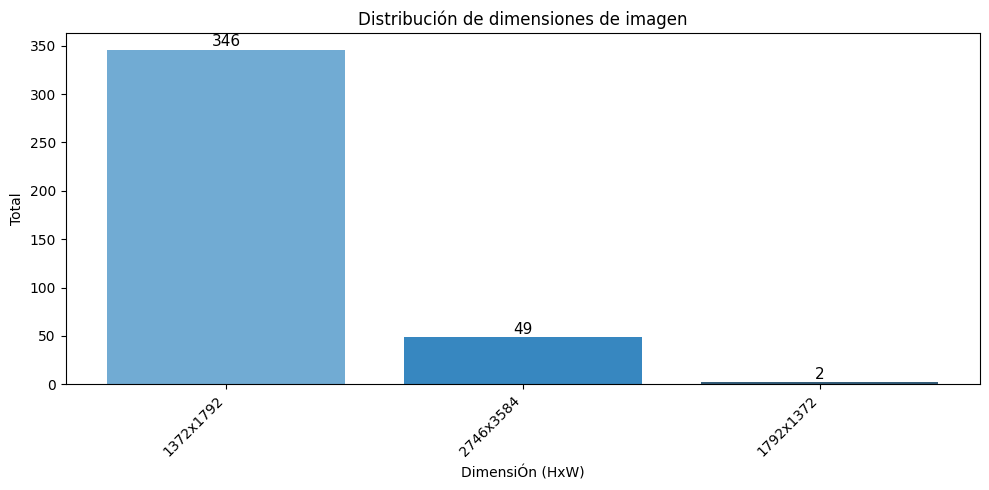

In [3]:
#Dimension

plot= plot_dimensions(get_images_dimensions(DATASET_PATH))
plot.savefig("experiments/plots/distribucion de dimensions", dpi= 100)


In [3]:
#resize de las imagenes
from src.data.preprocessment import resize_images
resize_images(root_path= DATASET_PATH, size= IMAGE_SIZE_XGBOOST)


Procesadas: 397 | Saltadas: 0


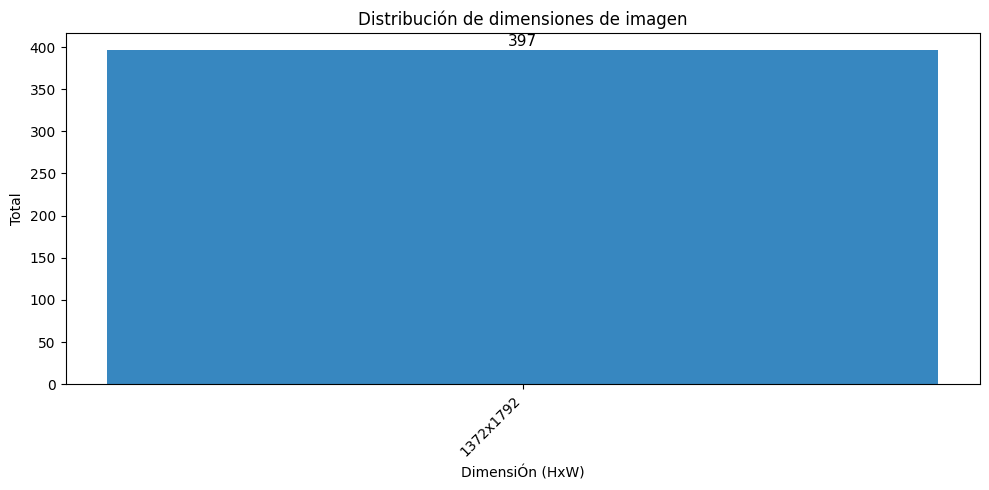

In [3]:
#comprobara

dimensions= get_images_dimensions(DATASET_PATH_XGBOOST)
dimensions
plot= plot_dimensions(dimensions)


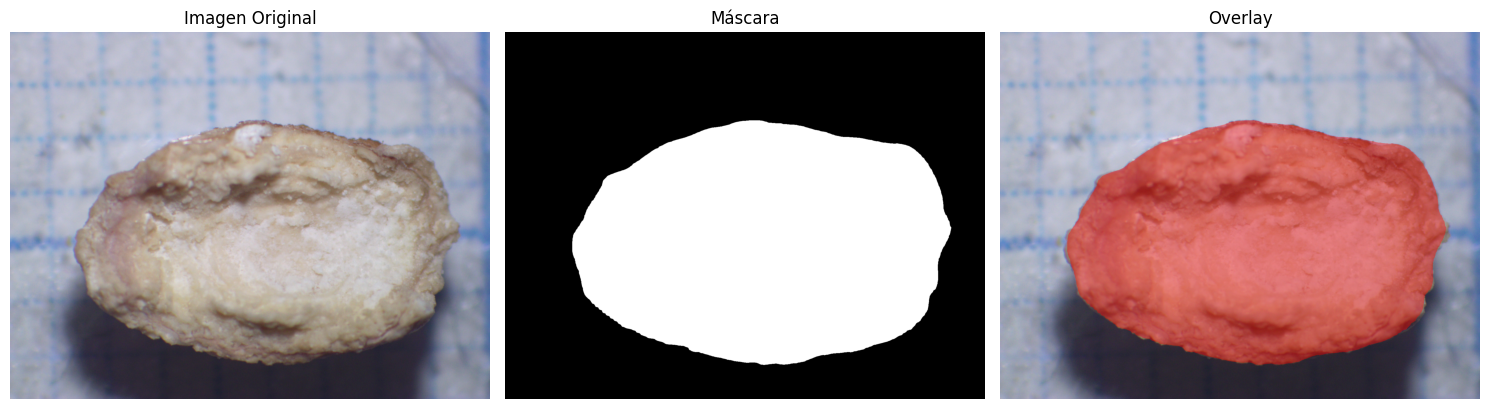

In [3]:


# 1. Definición de rutas corregidas
base_path = Path("DATASET/SECTION_SURFACE_DATASET/6/section")
image_name = "6_1860SE"

# Corrección 1: Usamos f-strings para combinar el nombre y la extensión dentro de Path
image_path = base_path / f"{image_name}.jpg"

# Corrección 2: La carpeta "MASKS" está en el directorio base, no dentro del archivo .jpg
mask_path = base_path / "MASKS" / f"{image_name}_mask.png"
overlay_path = base_path / "MASKS" / f"{image_name}_overlay.png"

# 2. Lectura de imágenes (asumiendo tu función existente)
image = load_image(image_path)
overlay= load_image(overlay_path)
mask= load_mask(mask_path)

# 3. Creación del plot horizontal (1 fila, 3 columnas)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Mostrar Imagen Original
axes[0].imshow(image)
axes[0].set_title("Imagen Original")
axes[0].axis('off')  # Oculta los ejes para una visualización más limpia

# Mostrar Máscara
axes[1].imshow(mask, cmap='gray')
axes[1].set_title("Máscara")
axes[1].axis('off')

# Mostrar Overlay
axes[2].imshow(overlay)
axes[2].set_title("Overlay")
axes[2].axis('off')

plt.tight_layout()
plt.show()
fig.savefig("experiments/plots/image_mascara_y_overlay.png", dpi= 100)

In [4]:
pares = {
    "1aI" :{
        "section": "1aI_1784SE_3.jpg",
        "surface": "1aI_1784SE_1.jpg",
        },
     "2a" :{
        "section": "2a_1940SE_2.jpg",
        "surface": "2a_1940SE.jpg",
        },
     "3bII" :{
        "section": "3bII_1985SE_2.jpg",
        "surface": "3bII_1985SE_1.jpg",
        },
     "4II-4I" :{
        "section": "4II_1825SE_2.jpg",
        "surface": "4II_1825SE.jpg",
        },
     "6" :{
        "section": "6_2365SE_2.png",
        "surface": "6_2365SE_1.png",
        },
     "8aI - 8aII" :{
        "section": "8aII_1874SE_2.jpg",
        "surface": "8aII_1874SE.jpg",
        }
}

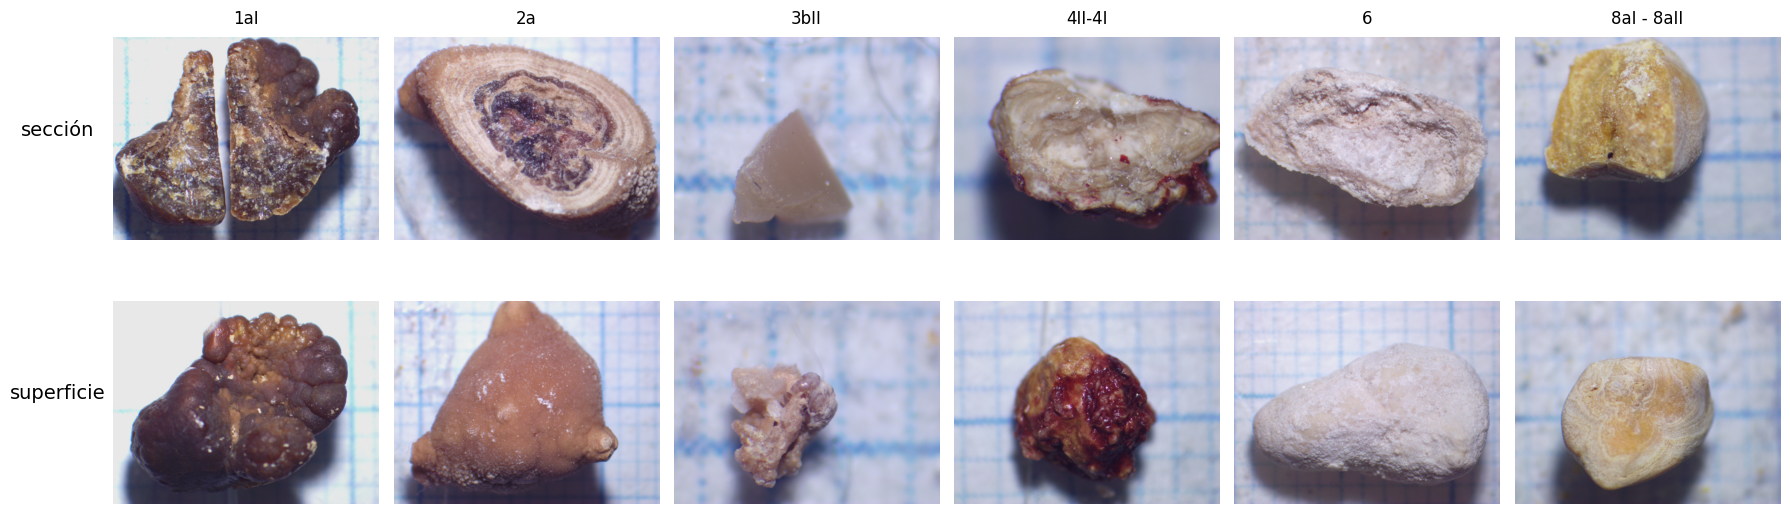

In [7]:


root = DATASET_PATH

fig, axes = plt.subplots(nrows=2, ncols=len(pares), figsize=(18, 6))

for i, (nombre_clase, imagenes) in enumerate(pares.items()):
    
    # Rutas de las imágenes 
    section_path = Path(root) / nombre_clase / "section" / imagenes["section"]
    surface_path = Path(root) / nombre_clase / "surface" / imagenes["surface"]
    
    section_image = load_image(section_path)
    surface_image = load_image(surface_path)
    
    # sección
    axes[0, i].imshow(section_image)
    axes[0, i].set_xticks([])
    axes[0, i].set_yticks([])
    
    # superfície
    axes[1, i].imshow(surface_image)
    axes[1, i].set_xticks([])
    axes[1, i].set_yticks([])
    
    # Ocultar los bordes
    for spine in axes[0, i].spines.values(): spine.set_visible(False)
    for spine in axes[1, i].spines.values(): spine.set_visible(False)
    #colorcar nombre de clases
    axes[0, i].set_title(nombre_clase, fontsize=12, pad=10)
    
    if i == 0:
        axes[0, 0].set_ylabel("sección", fontsize=14,rotation=0,  labelpad=40 )
        axes[1, 0].set_ylabel("superficie", fontsize=14,rotation=0,  labelpad=40)

plt.tight_layout()
plt.show()
fig.savefig("experiments/plots/imagenes_por_vista_y_clase.png", dpi= 100)